In [27]:
## Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np       
import plotly

# 1. Business Understanding
Goal: ?

# 2. Data Understanding

## 2.1 Load dataset

In [28]:
## Read *.csv file into pandas DataFrame
FILE_PATH = "data sets\hdb.csv"
df = pd.read_csv(FILE_PATH)
df

<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:2: SyntaxWarning: invalid escape sequence '\h'
C:\Users\jared\AppData\Local\Temp\ipykernel_28836\4095518941.py:2: SyntaxWarning: invalid escape sequence '\h'
  FILE_PATH = "data sets\hdb.csv"


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0
...,...,...,...,...,...,...,...,...,...,...,...
207870,2025-02,YISHUN,EXECUTIVE,826,YISHUN ST 81,10 TO 12,146.0,Maisonette,1988,62 years,1100888.0
207871,2025-04,YISHUN,EXECUTIVE,877,YISHUN ST 81,07 TO 09,142.0,Apartment,1987,61 years 09 months,988000.0
207872,2025-04,YISHUN,EXECUTIVE,828,YISHUN ST 81,04 TO 06,146.0,Maisonette,1988,61 years 09 months,975000.0
207873,2025-05,YISHUN,EXECUTIVE,828,YISHUN ST 81,04 TO 06,142.0,Apartment,1988,61 years 09 months,1000000.0


In [29]:
# Drop irrelevant columns
df = df.drop(['month', 'block', 'street_name', 'remaining_lease'], axis=1)
 
# To make the dataset more manageable
# Keep rows with the towns 'TAMPINES', 'BEDOK', 'PUNGGOL'
df = df[df['town'].isin(['TAMPINES', 'BEDOK', 'PUNGGOL'])]
 
# Keep rows with the word 'ROOM' in the flat_type column
df = df[df['flat_type'].str.contains('ROOM', case=False)]
 
df

,town,flat_type,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price
56,BEDOK,2 ROOM,04 TO 06,45.0,Improved,1978,238000.0
57,BEDOK,3 ROOM,04 TO 06,68.0,New Generation,1980,272000.0
58,BEDOK,3 ROOM,07 TO 09,59.0,Improved,1978,278000.0
59,BEDOK,3 ROOM,01 TO 03,68.0,New Generation,1980,280000.0
60,BEDOK,3 ROOM,01 TO 03,59.0,Improved,1976,280000.0
...,...,...,...,...,...,...,...
205836,TAMPINES,5 ROOM,04 TO 06,114.0,Improved,2017,840000.0
205837,TAMPINES,5 ROOM,04 TO 06,114.0,Improved,2017,812000.0
205838,TAMPINES,5 ROOM,10 TO 12,114.0,Improved,2017,910000.0
205839,TAMPINES,5 ROOM,04 TO 06,138.0,Model A,1985,808000.0


## 2.2 Summary Statistics

In [30]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37899 entries, 56 to 205840
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   town                 37899 non-null  object 
 1   flat_type            37899 non-null  object 
 2   storey_range         37899 non-null  object 
 3   floor_area_sqm       37899 non-null  float64
 4   flat_model           37899 non-null  object 
 5   lease_commence_date  37899 non-null  int64  
 6   resale_price         37899 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 2.3+ MB


In [31]:
## Check for missing data
df.isna().sum()

town                   0
flat_type              0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
resale_price           0
dtype: int64

In [32]:
## Describe data distribution
df.describe(include='all')

,town,flat_type,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price
count,37899,37899,37899,37899.000000,37899,37899.000000,3.789900e+04
unique,3,4,9,NaN,12,NaN,NaN
top,PUNGGOL,4 ROOM,04 TO 06,NaN,Model A,NaN,NaN
freq,14955,17578,8897,NaN,13907,NaN,NaN
mean,NaN,NaN,NaN,94.173567,NaN,1998.785245,5.080330e+05
std,NaN,NaN,NaN,19.495699,NaN,14.855024,1.430303e+05
min,NaN,NaN,NaN,37.000000,NaN,1972.000000,1.500000e+05
25%,NaN,NaN,NaN,82.000000,NaN,1985.000000,4.050000e+05
50%,NaN,NaN,NaN,93.000000,NaN,2000.000000,4.900000e+05
75%,NaN,NaN,NaN,110.000000,NaN,2014.000000,6.000000e+05


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

array([[<Axes: title={'center': 'floor_area_sqm'}>,
        <Axes: title={'center': 'lease_commence_date'}>],
       [<Axes: title={'center': 'resale_price'}>, <Axes: >]], dtype=object)

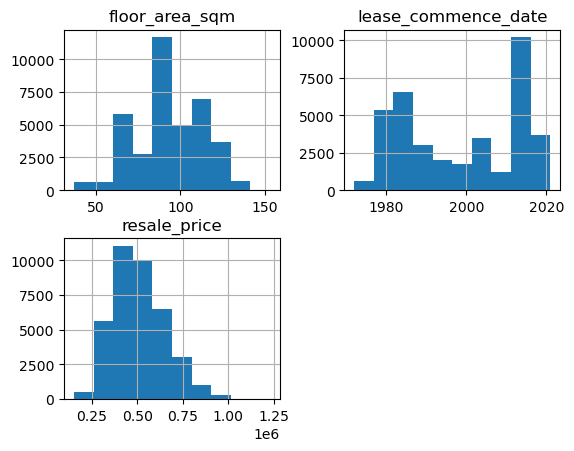

In [33]:
## Understanding distribution of target
df.hist()

### 2.3.1.2 Understanding distribution of features

<Axes: >

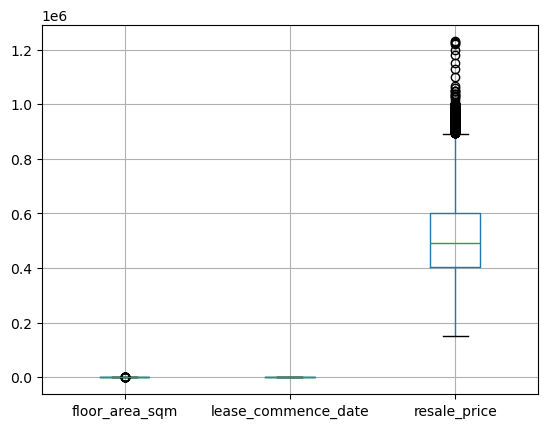

In [34]:
## Understanding distribution of features
df.boxplot()

### 2.3.2 Understanding relationship between variables

<function matplotlib.pyplot.show(close=None, block=None)>

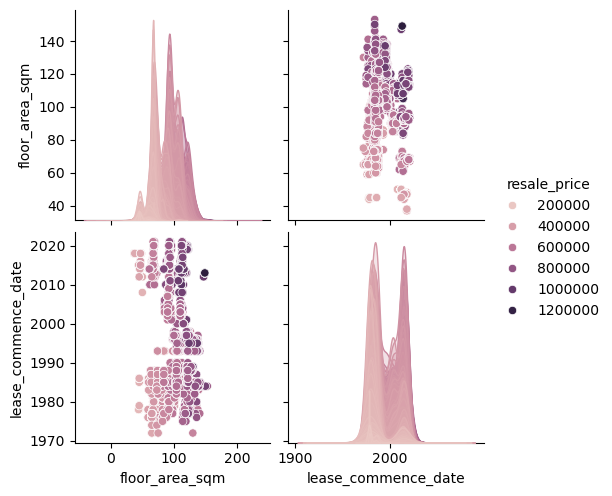

In [35]:
## Understanding relationship between variables
col_y = 'resale_price'
sns.pairplot(df, hue=col_y)
plt.show

# 3. Data Preparation

## 3.1 Data Cleaning

In [37]:
## Split data into features (X) and target (y)
y = df[col_y] ## Select target column
X = df.drop(col_y, axis = 1) ## Select feature column

In [38]:
## Clean data
X = pd.get_dummies(X, drop_first=True)

## 3.2 Train-Test Split

In [39]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split
test_size = 0.3
random_state = 2025
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=test_size, random_state=random_state)

# 4. Modelling

### 4.2 Train Model

In [40]:
## Initialise
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

## Save Model
import joblib
joblib.dump(dt, 'hdb_dt_model.pkl')

['hdb_dt_model.pkl']

In [41]:
# Split data into features (X) and target (y)
col_y = 'resale_price'
y = df[col_y]  # Select target column

col_irrelevant = [col_y]
X = df.drop(col_irrelevant, axis=1)  # Select feature columns

# One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)  # Remove redundant information

In [42]:
## Initialise
from sklearn.ensemble import GradientBoostingRegressor
gbt = GradientBoostingRegressor()
gbt.fit(X_train, y_train)

##

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [43]:
## Initialise
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
## Retrieve feature importance
df_dt_feat_impt = pd.DataFrame({
    'Feature': dt.feature_names_in,
    'Importance': dt.feature_importances_
})

## Obtain original feature from OHE feature names
df_dt_feat_impt['Feature'] = df_dt_feat_impt['Feature'].str.rsplit('_', n=1).str[0]
df_dt_feat_impt = df_dt_feat_impt.groupby('Feature')['Importance'].sum().sort_values(ascending=False)

## Calculate cumulative importance
df_dt_feat_impt['Cumulative importance'] = df_dt_feat_impt['Importance'].cumsum()

df_dt_feat_impt

AttributeError: 'DecisionTreeRegressor' object has no attribute 'feature_names_in'

NameError: name 'df_dt_feat_impt' is not defined

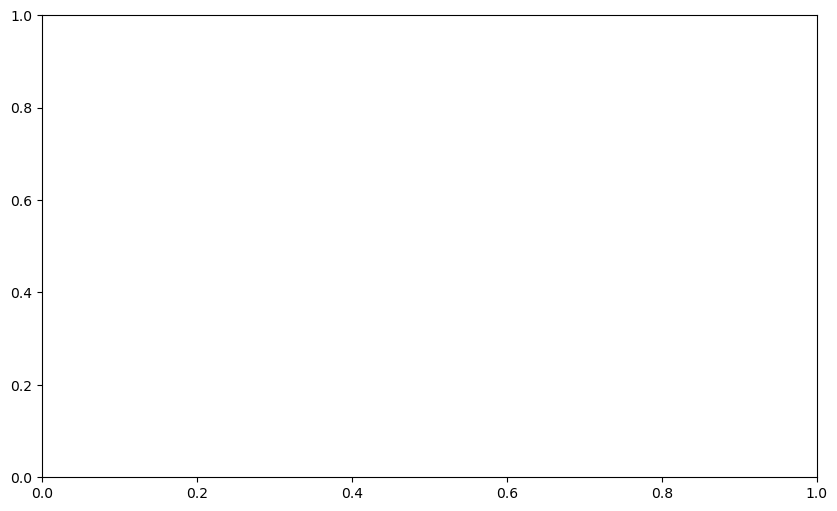

In [ ]:
## Plot feature importance and cumulative importance
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for feature importance
ax1.bar(df_dt_feat_impt['Feature'], df_dt_feat_impt['Importance'], color='skyblue')
ax1.set_xlabel('Features', size=15)
ax1.set_ylabel('Feature Importance', color='blue', size=15)
ax1.tick_params(axis='y', labelcolor='blue', labelsize=15)
ax1.set_xticklabels(df_dt_feat_impt['Feature'], rotation=45, ha='right', size=15)


# Line chart for cumulative importance
ax2 = ax1.twinx()
ax2.plot(df_dt_feat_impt['Feature'], df_dt_feat_impt['Cumulative importance'], color='red', 
         marker='o')
ax2.set_ylabel('Cumulative Importance', color='red', size=15)
ax2.tick_params(axis='y', labelcolor='red', labelsize=15)

plt.title('Feature Importance and Cumulative Importance', size=15)
plt.tight_layout()
plt.show()

# 5. Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

# Evaluate model
y_pred_dt = dt.predict(X_test)  # Prediction using model 1

mean_absolute_error(y_test, y_pred_dt)
mean_squared_error(y_test, y_pred_dt)
root_mean_squared_error(y_test, y_pred_dt)

74775.0692615235

In [ ]:
## Predict Value for evaluation
y_pred_dt = dt.predict(X_test)

In [ ]:
## Predict Value for evaluation
y_pred_gbt = gbt.predict(X_test)

In [ ]:
## Predict Value for evaluation
y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error

In [ ]:
## Evaluate model
mean_absolute_error(y_test, y_pred_dt)

59584.57339208039

In [ ]:
## Evaluate model
mean_absolute_error(y_test, y_pred_gbt)

59519.568424850884

In [45]:
## Evaluate model
mean_absolute_error(y_test, y_pred_rf)

58892.12783813317

In [46]:
## Predict

## Convert to OHE Pandas Dataframe
X_unseen = pd.read_csv(FILE_PATH)

col_df_X = df.drop(col_y, axis =1).columns
col_ohe = X.columns.tolist()
X_unseen = pd.DataFrame(X_unseen, columns=col_df_X)
X_unseen = pd.get_dummies(X_unseen, drop_first=True)
X_unseen = X_unseen.reindex(columns=col_ohe, fill_value=0)
## Predict for unseen data
X_unseen['Predicted Price'] = rf.predict(X_unseen)

## Compare with groundtruth
y_unseen = pd.read_csv(FILE_PATH)
X_unseen['Actual'] = y_unseen[col_y]
X_unseen

,floor_area_sqm,lease_commence_date,town_PUNGGOL,town_TAMPINES,flat_type_3 ROOM,flat_type_4 ROOM,flat_type_5 ROOM,storey_range_04 TO 06,storey_range_07 TO 09,storey_range_10 TO 12,...,flat_model_Improved,flat_model_Model A,flat_model_Model A-Maisonette,flat_model_New Generation,flat_model_Premium Apartment,flat_model_Premium Apartment Loft,flat_model_Simplified,flat_model_Standard,Predicted Price,Actual
0,44.0,1979,False,False,False,False,False,False,False,True,...,True,False,False,False,False,False,False,False,263325.515238,232000.0
1,67.0,1978,False,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,309674.340485,250000.0
2,67.0,1980,False,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,287179.732873,262000.0
3,68.0,1980,False,False,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,328378.511075,265000.0
4,67.0,1980,False,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,287179.732873,265000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207870,146.0,1988,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,788827.410190,1100888.0
207871,142.0,1987,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,718758.108000,988000.0
207872,146.0,1988,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,747054.396242,975000.0
207873,142.0,1988,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,730058.785957,1000000.0
